In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from utilities import create_sine_data
from laplace_models import NeuralNetworkRegression


500 -4.059611137934686
1000 -8.117419307349085
1500 -8.517837340624439
2000 -8.62712938645354


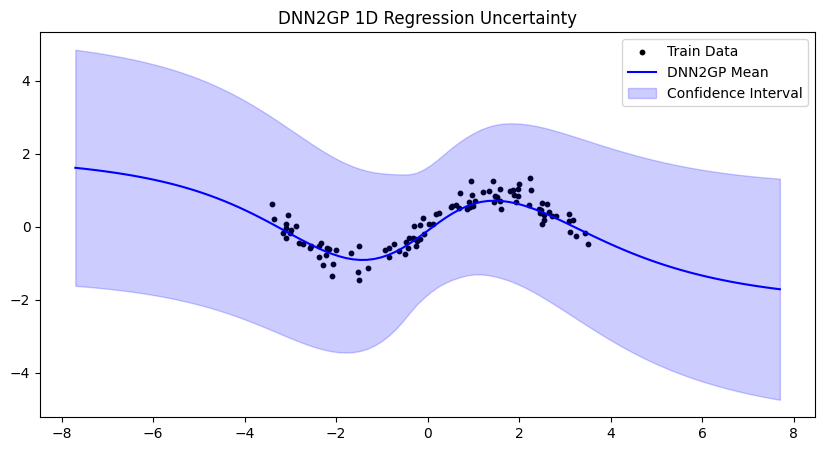

In [2]:

# 1. Generate the synthetic data with a gap
X_train, y_train, X_test, y_test = create_sine_data(n=100, n_test=100, offset=0, noise_sigma=0.25)

# 2. Train the Neural Network and compute the Laplace Approximation
# delta is the prior precision (regularization), sigma_noise is the data noise
model = NeuralNetworkRegression(X_train, y_train, delta=1.0, sigma_noise=0.25, 
                                n_epochs=2000, hidden_size=32)

# 3. Predict using the GP representation (using the Jacobian 'J' approximation)
mean_f, var_f = model.posterior_predictive_f(X_test, hessian_approx='J', 
                                             compute_cov=True, diag_only=True)
std_f = np.sqrt(var_f)

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color='black', s=10, label='Train Data')
plt.plot(X_test, mean_f, color='blue', label='DNN2GP Mean')
plt.fill_between(X_test.flatten(), mean_f - 2*std_f, mean_f + 2*std_f, 
                 color='blue', alpha=0.2, label='Confidence Interval')
plt.legend()
plt.title("DNN2GP 1D Regression Uncertainty")
plt.show()

Training MAP estimate...
Computing DNN2GP quantities...


  0%|          | 0/1 [00:02<?, ?it/s]


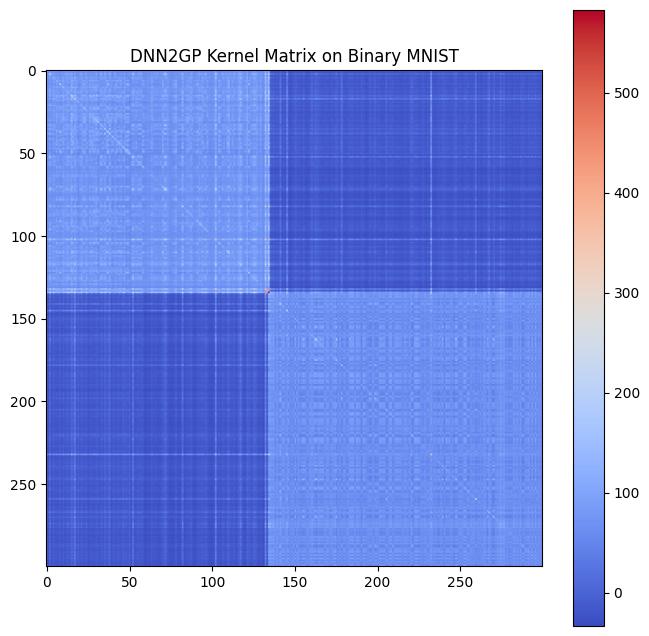

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from laplace_models import NeuralNetworkClassification
from dnn2gp import compute_dnn2gp_quantities, compute_kernel
from torch.utils.data import TensorDataset, DataLoader

# 1. Load a subset of MNIST
dataset = Dataset('mnist')
# Increase batch size slightly since we will filter out ~80% of the data
train_loader = dataset.get_train_loader(batch_size=1500, shuffle=False)
X_batch, y_batch = next(iter(train_loader))

# --- Filter for Binary MNIST (digits 0 and 1) ---
binary_mask = (y_batch == 0) | (y_batch == 1)
X_batch_binary = X_batch[binary_mask][:300]
y_batch_binary = y_batch[binary_mask][:300]

# 2. Train the simple network for the MAP estimate
X_np = X_batch_binary.view(X_batch_binary.shape[0], -1).numpy()
# FIX 1: Cast labels to float64 to match PyTorch's internal double precision requirements
y_np = y_batch_binary.numpy().astype(np.float64)

print("Training MAP estimate...")
model_wrapper = NeuralNetworkClassification(X_np, y_np, delta=1.0, n_epochs=500, hidden_size=50)

# 3. Compute the Jacobians and transform them into the NTK Kernel
model = model_wrapper.model 
device = 'cpu'

# FIX 2: Create a DataLoader specifically for the filtered binary data so we only compute Jacobians for 0s and 1s
binary_dataset = TensorDataset(X_batch_binary.view(X_batch_binary.shape[0], -1), y_batch_binary.to(torch.float64))
binary_loader = DataLoader(binary_dataset, batch_size=300)

print("Computing DNN2GP quantities...")
Jacobians, pred_mean_GP, labels = compute_dnn2gp_quantities(model, binary_loader, device, limit=300)

# 4. Compute the NxN Kernel matrix summing over the class dimensions
K = compute_kernel(Jacobians.numpy(), agg_type='sum')

# 5. Plot the Kernel Matrix
# Sort the kernel by labels to see the block-diagonal class structure
sorted_indices = labels.numpy().argsort()
K_sorted = K[sorted_indices][:, sorted_indices]

plt.figure(figsize=(8, 8))
plt.imshow(K_sorted, cmap='coolwarm')
plt.colorbar()
plt.title("DNN2GP Kernel Matrix on Binary MNIST")
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_586549/1516912023.py:36: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('Hyperparameter $\delta$')


500 16.47178606456378
1000 6.714882596759461
Delta: 0.01 | Log Marginal Likelihood: -12501.52
500 16.50237247515599
1000 6.758124668334033
Delta: 0.1 | Log Marginal Likelihood: -12768.51
500 16.84703145472178
1000 7.259143632910311
Delta: 1.0 | Log Marginal Likelihood: -13057.69
500 26.262016777352343
1000 10.033498901761343
Delta: 10.0 | Log Marginal Likelihood: -13636.93
500 151.0875770696124
1000 146.50454837964162
Delta: 100.0 | Log Marginal Likelihood: -40744.40


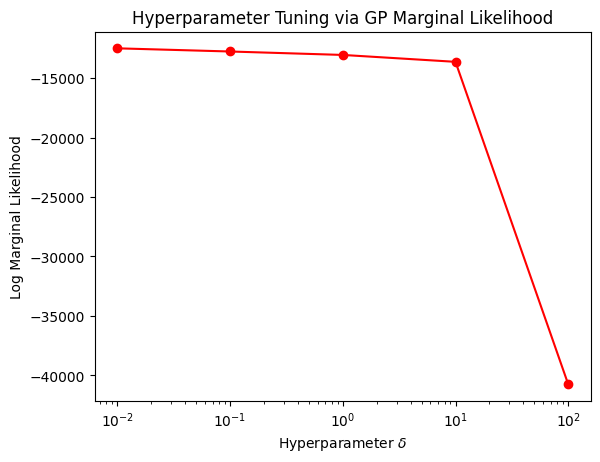

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from utilities import create_sine_data
from laplace_models import NeuralNetworkRegression
from dual_models import DualGPRegression

X_train, y_train= create_sine_data(n=100, n_test=0, offset=0, noise_sigma=0.25)

deltas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
log_marginal_likelihoods = []

for delta in deltas_to_test:
    # 1. Train the network to find w_* for the current delta
    model = NeuralNetworkRegression(X_train, y_train, delta=delta, sigma_noise=0.25, n_epochs=1000)
    
    # 2. Extract Jacobians (Us) and residuals (vs) using the GGN approximation
    Us, _ = model.UsSs(hessian_approx='J')
    vs = model.vs(hessian_approx='J')
    
    # 3. Formulate the transformed linear model variables
    X_hat = Us
    y_hat = Us @ model.theta_star - vs
    
    # 4. Initialize the Dual GP model
    S_0 = np.eye(len(model.theta_star)) / delta
    gp = DualGPRegression(X_hat, y_hat, s_noise=0.25, m_0=model.theta_star, S_0=S_0)
    
    # 5. Compute the LML
    lml = gp.log_marginal_likelihood()
    log_marginal_likelihoods.append(lml)
    print(f"Delta: {delta} | Log Marginal Likelihood: {lml:.2f}")

# Plotting the LML curve
plt.plot(deltas_to_test, log_marginal_likelihoods, marker='o', color='red')
plt.xscale('log')
plt.xlabel('Hyperparameter $\delta$')
plt.ylabel('Log Marginal Likelihood')
plt.title('Hyperparameter Tuning via GP Marginal Likelihood')
plt.show()